# Kaplan-Meier Survival Analysis 

In Excel : https://github.com/lukashalim/ExcelSurvival (Tutorial : https://www.youtube.com/watch?v=7R0iBJZ6QLY)

In Python : https://lifelines.readthedocs.io/en/latest/Survival%20analysis%20with%20lifelines.html

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_405, convert2np

from scipy.stats import f_oneway, chi2_contingency

from sklearn.metrics.cluster import contingency_matrix

from lifelines import KaplanMeierFitter

In [2]:
data_df = get_hfpef_405(get_mortal_hospitalize = True)

In [3]:
cols = ['time to mortality after diagnosis', 
        'time to HF hospitalization after diagnosis', 
        'time to MACE',
        'censor (death)', 
        'censor (HF)',
        'censor (MACE)',
        ]

kaplan_df = data_df[cols]
data_df = data_df.drop(cols, axis = 1)

In [5]:
kaplan_df.describe()

,time to mortality after diagnosis,time to HF hospitalization after diagnosis,time to MACE,censor (death),censor (HF),censor (MACE)
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,-0.623116,0.449749,0.520101,0.894472,0.489950,0.454774
std,1.243084,1.849838,1.873411,0.307619,0.500528,0.498577
min,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000
50%,-1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000


In [6]:
col_fix = {'death':'time to mortality after diagnosis', 'HF':'time to HF hospitalization after diagnosis', 'MACE':'time to MACE'}

In [7]:
for k, v in col_fix.items():
    print(k ,':', v)
    kaplan_df[f'E_{k}'] = kaplan_df[f'censor ({k})'].astype('bool')
    # kaplan_df[f'E_{k}'] = kaplan_df[v] >= 0
    
    kaplan_df.loc[kaplan_df[v] < 0, v] = 0
    kaplan_df[f'T_{k}'] = kaplan_df[v]

death : time to mortality after diagnosis
HF : time to HF hospitalization after diagnosis
MACE : time to MACE


In [8]:
kaplan_df['E_mortal'] = kaplan_df['time to mortality after diagnosis'] >= 0
kaplan_df['T_mortal'] = kaplan_df['time to mortality after diagnosis']
kaplan_df.loc[kaplan_df['T_mortal'] < 0, 'T_mortal'] = 0

kaplan_df.loc[kaplan_df['time to mortality after diagnosis'] < 0, 'time to mortality after diagnosis'] = 0

In [9]:
# kaplan_df['E_hf'] = kaplan_df['time to HF hospitalization after diagnosis'] >= 0
# kaplan_df['T_hf'] = kaplan_df['time to HF hospitalization after diagnosis']
# kaplan_df.loc[kaplan_df['T_hf'] < 0, 'T_hf'] = 0

# kaplan_df.loc[kaplan_df['time to HF hospitalization after diagnosis'] < 0, 'time to HF hospitalization after diagnosis'] = 0

## Get Cluster

In [11]:
from methods import get_sc_pred, get_p_ci
from utils import get_score, score_columns, plot_clustering_score, plot_contingency_matrix, plot_bic_aic

import matplotlib.pyplot as plt
%matplotlib inline
# plt.style.use('ggplot')

In [12]:
plt.rcParams["font.family"] = "Gill Sans MT"
plt.rc('axes', unicode_minus=False)

In [13]:
lbl_colname= ['Death', 'CV death', 'Major cardiac events', 'HF re-hospitalization']

## Analysis

### 1. All Features

In [14]:
# from lifelines.datasets import load_dd

# data = load_dd()
# data.head()

In [15]:
# T = data["duration"]
# E = data["observed"]

# kmf = KaplanMeierFitter()
# kmf.fit(T, event_observed=1-E)

# kmf.survival_function_.plot()
# plt.title('Survival function of political regimes');

In [16]:
X, y, feature_list = convert2np(data_df, lbl_colname)
y_pred = get_sc_pred(3, X)
kaplan_df['group'] = y_pred

C:\Users\sguly\Documents\HFpEF\preproc.py:55: UserWarning: Warning...........selected_feat is not given, set to 0 where all features are used.
  warnings.warn("Warning...........selected_feat is not given, set to 0 where all features are used.")


In [17]:
cmat1 = contingency_matrix(data_df['Major cardiac events'], y_pred)
cmat1

array([[ 57, 109,  15],
       [ 89,  62,  66]], dtype=int64)

In [18]:
df_c = pd.read_excel("HFpEF_allfeat_spectral_3clus_405samples.xlsx", sheet_name="cluster", usecols=[1,2])
cmat2 = contingency_matrix(data_df['Major cardiac events'], df_c['cluster'])
cmat2

array([[ 57, 109,  15],
       [ 89,  62,  66]], dtype=int64)

In [19]:
assert(np.all(cmat1==cmat2))

In [20]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([146, 171,  81], dtype=int64))

In [21]:
# T = kaplan_df["T_death"]
# E = kaplan_df["E_death"]

# kmf = KaplanMeierFitter()
# kmf.fit(T, event_observed=1-E)

# kmf.survival_function_.plot()
# plt.title('Survival function of political regimes');

In [22]:
# ax = plt.subplot(111)

# kmf = KaplanMeierFitter()

# for name, grouped_df in kaplan_df.groupby('group'):
#     kmf.fit(grouped_df["time to mortality after diagnosis"], grouped_df["HF re-hospitalization"], label=name)
#     kmf.plot_survival_function(ax=ax)
# ax.set_xlabel('Years to mortality after diagnosis')
# ax.set_ylabel('Percent Survival')

In [23]:
# ax = plt.subplot(111)

# kmf = KaplanMeierFitter()

# for name, grouped_df in kaplan_df.groupby('group'):
#     kmf.fit(grouped_df["T_mortal"], event_observed = grouped_df["E_mortal"], label=f'cluster {name}')
#     kmf.plot_survival_function(ax=ax)
# ax.set_xlabel('Years to mortality after diagnosis')
# ax.set_ylabel('Percent Survival')

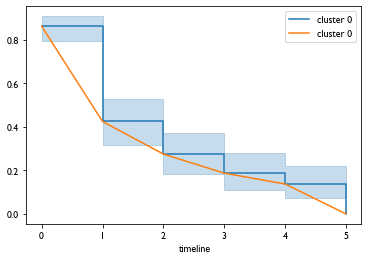

In [24]:
kmf = KaplanMeierFitter()
ax = plt.subplot(111)
for name, grouped_df in kaplan_df.groupby('group'):
    kmf.fit(grouped_df["T_MACE"], event_observed=1-grouped_df["E_MACE"].astype('int'), label=f'cluster {name}')
    kmf.plot_survival_function(ax=ax)
    kmf.survival_function_.plot(ax=ax)
    break

In [25]:
# ax = plt.subplot(111)

# kmf = KaplanMeierFitter()

# for name, grouped_df in kaplan_df.groupby('group'):
#     kmf.fit(grouped_df["T_MACE"], event_observed=1-grouped_df["E_MACE"].astype('int'), label=f'cluster {name}')
#     kmf.plot_survival_function(ax=ax)
# ax.set_xlabel('Years to mortality after diagnosis')
# ax.set_ylabel('Percent Survival')

In [26]:
def plot_kaplan_meier(k_df):
    plt.figure(figsize=(20,4))
    for i, (k, v) in enumerate(col_fix.items()):
        ax = plt.subplot(1, len(col_fix), i+1)

        kmf = KaplanMeierFitter()

        for name, grouped_df in k_df.groupby('group'):
            kmf.fit(grouped_df[f"T_{k}"], event_observed=1-grouped_df[f"E_{k}"].astype('int'), label=f'cluster {name}')
            kmf.plot_survival_function(ax=ax)
        ax.set_xlabel(v)
        ax.set_ylabel('Percent Survival')
        ax.set_title(k)

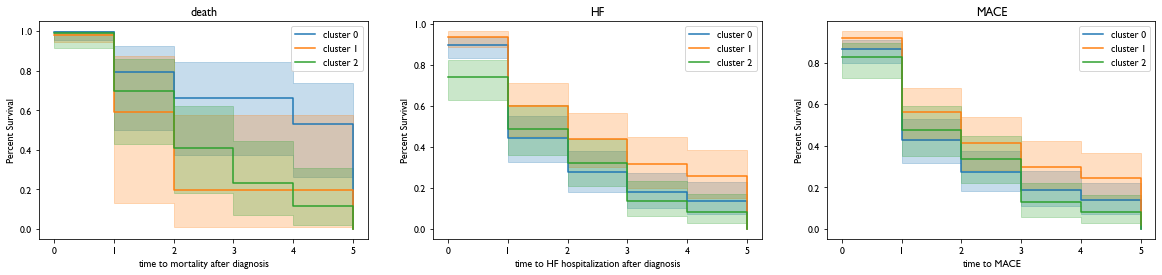

In [27]:
plot_kaplan_meier(kaplan_df)

### 2. Selected Features

In [28]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=1)
y_pred = get_sc_pred(3, X)
kaplan_df['group'] = y_pred

In [29]:
cmat1 = contingency_matrix(data_df['Major cardiac events'], y_pred)
cmat1

array([[ 55, 109,  17],
       [ 82,  61,  74]], dtype=int64)

In [30]:
df_c = pd.read_excel("HFpEF_selfeat_spectral_3clus_405samples.xlsx", sheet_name="cluster", usecols=[1,2])
cmat2 = contingency_matrix(data_df['Major cardiac events'], df_c['cluster'])
cmat2

array([[ 55, 109,  17],
       [ 82,  61,  74]], dtype=int64)

In [31]:
assert(np.all(cmat1==cmat2))

In [32]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([137, 170,  91], dtype=int64))

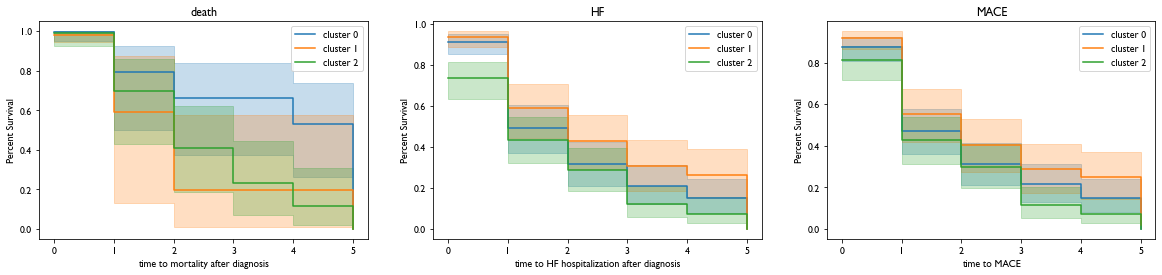

In [33]:
plot_kaplan_meier(kaplan_df)

### 3. Selected Feature Based on PCA

In [34]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=2)
y_pred = get_sc_pred(3, X)
kaplan_df['group'] = y_pred

In [35]:
cmat1 = contingency_matrix(data_df['Major cardiac events'], y_pred)
cmat1

array([[ 61, 101,  19],
       [ 80,  53,  84]], dtype=int64)

In [36]:
df_c = pd.read_excel("HFpEF_onefeat_spectral_3clus_405samples.xlsx", sheet_name="cluster", usecols=[1,2])
cmat2 = contingency_matrix(data_df['Major cardiac events'], df_c['cluster'])
cmat2

array([[ 61, 101,  19],
       [ 80,  53,  84]], dtype=int64)

In [37]:
assert(np.all(cmat1==cmat2))

In [38]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([141, 154, 103], dtype=int64))

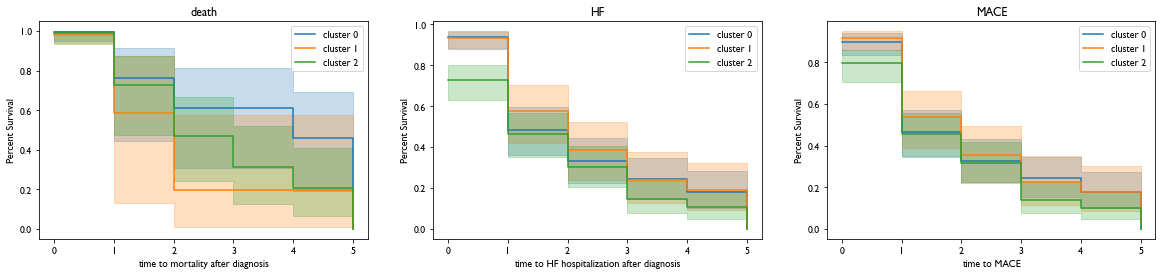

In [39]:
plot_kaplan_meier(kaplan_df)